# Problem B: Solve Pressure Field in 2D Heterogeneous Porous Media

Consider a square domain $\Omega = [0,1]^2$ representing a heterogeneous porous medium composed of two distinct material phases with significantly different permeabilities, for instance, high-permeability sandstone inclusions embedded in a low-permeability mudstone matrix. Such heterogeneous structures arise frequently in subsurface flow engineering, including groundwater modeling, hydrocarbon reservoir simulation, and fuel cell design. Near the interface between the two phases, the pressure gradient exhibits sharp transitions, making this a classical benchmark for testing the robustness of PDE solvers under non-smooth coefficients.

The permeability field $\mu(x)$ is defined as:

$$
\mu(x) =
\begin{cases}
\mu_1 = 10, & x \in \Omega_1 \quad \text{(high-permeability phase, e.g., sandstone)} \\
\mu_2 = 2,  & x \in \Omega_2 \quad \text{(low-permeability phase, e.g., mudstone)}
\end{cases}
$$

The specific two-phase microstructure (i.e., the geometric distribution of $\Omega_1$ and $\Omega_2$) is provided in the dataset. The pressure field $u(x)$ satisfies the following Darcy flow equation:

$$
-\nabla \cdot \left(\mu(x)\,\nabla u\right) = f, \quad x \in \Omega \tag{1}
$$

where
- $u(x):$ pressure field in the porous medium
- $\mu(x):$ spatially varying permeability field
- $f = 0:$ source term (no internal source/sink)
- $\Omega = [0,1]^2:$ square computational domain

The boundary conditions are prescribed as follows, driving fluid flow from the high-pressure inlet on the left to the low-pressure outlet on the right:

$$
g_D(x) =
\begin{cases}
1, & x_1 = 0 \quad \text{(left boundary, high-pressure inlet)} \\
0, & x_1 = 1 \quad \text{(right boundary, low-pressure outlet)} \\
\text{linear interpolation}, & x_2 = 0 \text{ or } 1 \quad \text{(top and bottom boundaries)}
\end{cases}
$$

## Task: Solve the pressure field $u(x)$

In this task, the permeability field $\mu(x)$ is provided as a $128 \times 128$ pixel matrix — that is, the domain is subdivided into $128 \times 128$ cells, each with a constant permeability value. Using this permeability field, apply a suitable method introduced in the lecture to solve for the pressure field $u(x)$ in the heterogeneous porous medium.

### The Goals
- Please select a suitable deep learning method for solving this forward problem to compute the pressure field $u(x)$, and explain the reason for using it.
- Report your setups for the implementation, such as network structure, activation function, optimizer (with learning rate), epoch (with batch size), loss weights, and other tricks that are used for improvement.
- Compute the $L^2$ relative error (on the testing dataset) at each training epoch and plot the `Error vs. epoch` curve (and report the final error). The $L^2$ relative error between the prediction $u_\text{pred}$ and the reference $u_\text{true}$ is defined as follows:

$$
\text{error} = \sqrt{\frac{\sum_i^n \left| u_\text{pred}(x_i) - u_\text{true}(x_i) \right|^2}{\sum_i^n \left| u_\text{true}(x_i) \right|^2}}
$$

- Plot the predicted solution (and the ground truth reference) and the pointwise absolute error using separate figures with `matplotlib`.

### Dataset

The permeability field and the reference solution are provided in the dataset ProblemB_dataset.h5:

- `mu_field`: the permeability field $\mu(x)$, represented as a $128 \times 128$ pixel matrix, where each cell has a constant permeability value (available for training)
- `x_test`: the locations where the reference solution is evaluated (Used for computing error and should **not** be used for training)
- `u_test`: the reference pressure field values (used for computing error and should **not** be used for training)
- Link to dataset: [https://www.kaggle.com/datasets/yhzang32/dno4pdes](https://www.kaggle.com/datasets/yhzang32/dno4pdes)

## Method: The Deep Ritz Method

**Why not a strong-form PINN?** The strong residual $-\nabla\cdot(\mu \nabla u) = \mu \Delta u + \nabla\mu\cdot\nabla u$
requires differentiating the permeability. Here $\mu(x)$ is *piecewise constant* ($\mu_1 = 10$, $\mu_2 = 2$ on a
$128\times128$ pixel microstructure): $\nabla \mu$ is zero inside each phase and undefined (a Dirac layer) at the
interfaces — exactly where the physics (flux continuity, kinked pressure) happens. A strong-form PINN therefore
minimizes a residual that is *wrong* at the interfaces. Moreover, the true solution has a discontinuous normal
derivative there, which a smooth network can never satisfy in strong form.

**Why Deep Ritz?** The Darcy problem is symmetric elliptic, so its weak solution is the unique minimizer of the
energy functional (with $f = 0$):

$$
u^* = \arg\min_{u \in H^1_g(\Omega)} E(u), \qquad
E(u) = \int_\Omega \frac{\mu(x)}{2}\,|\nabla u(x)|^2 \, dx .
$$

The energy involves only **first** derivatives of $u$ and only **evaluations** of $\mu$ — the discontinuous
coefficient is never differentiated. We approximate $u$ by a neural network $u_\theta$, estimate $E$ by Monte-Carlo
integration, and minimize with Adam. Because the Monte-Carlo estimator is *unbiased*, decreasing the loss genuinely
decreases the energy — there is no quadrature error for the optimizer to exploit.

*Remark (method selection).* We also prototyped the weak-form ParticleWNN for this problem. Its localized
test-function integrals must be evaluated by quadrature over small balls; with a pixelated coefficient the quadrature
error at interfaces is significant, and the optimizer exploits it (training loss decreases while the true error
increases). Deep Ritz reached a $\sim 2\times$ lower $L^2$ error at a fraction of the cost, so it is the method of
choice here.

**Design choices (tricks) used here**
1. **Hard boundary constraint.** The prescribed Dirichlet data (left $=1$, right $=0$, linear interpolation on
   top/bottom) is exactly the function $g(x) = 1 - x_1$ on all four boundaries. The ansatz
   $$u_\theta(x) = (1 - x_1) + x_1(1-x_1)\,x_2(1-x_2)\,\mathcal{N}(x)$$
   satisfies the boundary conditions *exactly* — no boundary penalty, no loss weight to tune, and the energy
   minimization is unconstrained.
2. **Stratified (per-pixel) sampling.** Instead of plain uniform sampling we draw exactly one uniformly jittered
   point inside each of the $128\times128$ pixel cells per epoch. Since $\mu$ is constant per pixel, this
   stratification removes most of the Monte-Carlo variance of the energy estimate.
3. **Input normalization** $x \mapsto 2x - 1$ for the $\tanh$ network.
4. **Collocation resampling**: a fresh jitter every epoch acts like an infinite training set.

In [ ]:

# Imports, reproducibility, and global configuration

import os
import time
import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.autograd import grad
import matplotlib.pyplot as plt
from tqdm import trange


SEED = 1234
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
dtype = torch.float32
print('Running on:', device)


RESOLUTION = 128                  # pixels per side of the permeability field
LAYERS = [2, 80, 80, 80, 80, 1]   # network for the pressure u(x)
EPOCHS = 6000
LR = 1e-3
LR_STEP, LR_GAMMA = 1200, 0.6

DATA_PATH = os.path.join('ProblemB_dataset.h5')
CKPT_DIR = os.path.join('checkpoints', 'problemB')
os.makedirs(CKPT_DIR, exist_ok=True)

Running on: cuda:0


mu_field: (128, 128) | x_test: (16384, 2) | u_test: (16384, 1)


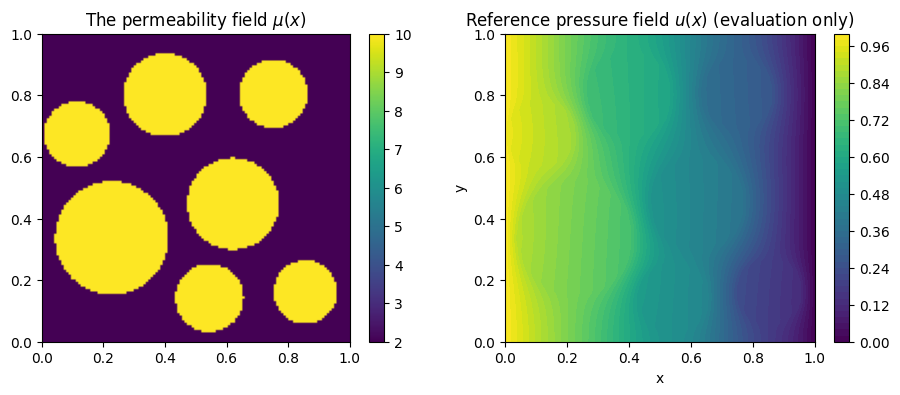

In [ ]:

# Load the dataset and visualize the permeability / reference

with h5py.File(DATA_PATH, 'r') as f:
    mu_field = torch.tensor(np.array(f['mu_field']), dtype=dtype)          # (128,128) pixels
    x_test = torch.tensor(np.array(f['x_test']), dtype=dtype)              # (16384, 2)
    u_test = torch.tensor(np.array(f['u_test']), dtype=dtype).reshape(-1, 1)  # reference, not for training
print('mu_field:', tuple(mu_field.shape), '| x_test:', tuple(x_test.shape), '| u_test:', tuple(u_test.shape))


def fun_mu(x, mu=mu_field, resolution=RESOLUTION):
    """Nearest-pixel lookup of the permeability field at positions x (N, 2)."""
    m = mu.reshape(1, -1).to(x.device)
    delta = 1. / (resolution - 1)
    x_loc = torch.floor(x[..., 0] / delta + 0.5).long().clamp(0, resolution - 1)
    y_loc = torch.floor(x[..., 1] / delta + 0.5).long().clamp(0, resolution - 1)
    return m[0, y_loc * resolution + x_loc].unsqueeze(-1)


x_test_dev = x_test.to(device)
u_test_dev = u_test.to(device)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cntr = axes[0].imshow(mu_field, origin='lower', extent=[0, 1, 0, 1])
axes[0].set_title(r'The permeability field $\mu(x)$'); plt.colorbar(cntr, ax=axes[0])
cntr = axes[1].contourf(x_test[:, 0].reshape(128, 128), x_test[:, 1].reshape(128, 128),
                        u_test.reshape(128, 128), levels=50)
axes[1].set_title(r'Reference pressure field $u(x)$ (evaluation only)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y'); plt.colorbar(cntr, ax=axes[1])
plt.show()

### Step 1: Approximating $u(x)$ with a neural network (hard boundary constraint)

In [ ]:

# Neural network architecture (implemented from scratch)

class MLP(nn.Module):
    """Fully-connected network: Linear layers with tanh activations."""

    def __init__(self, layers_list: list, dtype=None):
        super(MLP, self).__init__()
        net = []
        hidden_in = layers_list[0]
        for hidden in layers_list[1:]:
            net.append(nn.Linear(hidden_in, hidden, dtype=dtype))
            hidden_in = hidden
        self.net = nn.Sequential(*net)

    def forward(self, x):
        x = 2. * x - 1.                      # normalize [0,1]^2 -> [-1,1]^2
        for layer in self.net[:-1]:
            x = torch.tanh(layer(x))
        return self.net[-1](x)


class PressureNet(nn.Module):
    """u_theta(x) = (1 - x1) + x1(1-x1) x2(1-x2) N(x).

    The lift (1 - x1) equals the prescribed Dirichlet data on all four
    boundaries (left=1, right=0, linear on top/bottom), and the bubble
    x1(1-x1)x2(1-x2) vanishes there => the BCs hold exactly.
    """

    def __init__(self, layers_list: list, dtype=None):
        super(PressureNet, self).__init__()
        self.net = MLP(layers_list, dtype=dtype)

    def forward(self, x):
        x1, x2 = x[..., 0:1], x[..., 1:2]
        return (1. - x1) + x1 * (1. - x1) * x2 * (1. - x2) * self.net(x)


model_u = PressureNet(LAYERS, dtype=dtype).to(device)
print('Trainable parameters:', sum(p.numel() for p in model_u.parameters()))

Trainable parameters: 19761


### Step 2: The Deep Ritz loss

$$
\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N} \frac{\mu(x_i)}{2}\,\big|\nabla u_\theta(x_i)\big|^2
\;\approx\; E(u_\theta) \quad (\text{up to the constant factor } |\Omega| = 1),
$$

with $\nabla u_\theta$ from automatic differentiation and $\mu(x_i)$ from the nearest-pixel lookup `fun_mu`.

In [ ]:

# The Deep Ritz loss (Monte-Carlo energy) and the error metric

class DeepRitzLoss(object):
    """Ritz energy E(u) = int mu/2 |grad u|^2 dx (f = 0), estimated by stratified MC."""

    def __init__(self, u_model, resolution=RESOLUTION):
        self.u_model = u_model
        self.delta = 1. / (resolution - 1)
        # pixel-cell centers of the 128 x 128 grid (stratification cells)
        line = torch.linspace(0., 1., resolution)
        self.centers = torch.stack(torch.meshgrid(line, line, indexing='ij'), -1).reshape(-1, 2).to(device)

    def sample_stratified(self):
        """One uniformly jittered point inside every pixel cell (16384 points)."""
        jitter = (torch.rand_like(self.centers) - 0.5) * self.delta
        return (self.centers + jitter).clamp(0., 1.)

    def loss_energy(self, x):
        """Monte-Carlo estimate of the Ritz energy at sample points x."""
        x = x.requires_grad_(True)
        u = self.u_model(x)
        du = grad(inputs=x, outputs=u, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        mu = fun_mu(x.detach())
        return torch.mean(0.5 * mu * torch.sum(du ** 2, dim=-1, keepdim=True))

    @torch.no_grad()
    def get_error(self, x_test, u_test):
        """L2 relative error on the testing grid (evaluation only)."""
        u_pred = self.u_model(x_test)
        return torch.sqrt(torch.sum((u_pred - u_test) ** 2) / torch.sum(u_test ** 2)).item()


loss_fn = DeepRitzLoss(model_u)
print(f'Initial energy = {loss_fn.loss_energy(loss_fn.sample_stratified()).item():.4f}')

Initial energy = 2.5169


### Step 3: Training

Adam on the Monte-Carlo energy with a step learning-rate decay. Every epoch we resample the stratified points,
take one optimizer step, record the $L^2$ relative test error (required *Error vs. epoch* curve), and checkpoint
the network at the lowest training energy seen so far (the test set is never used for model selection).

In [ ]:

# Training loop (with per-epoch validation and checkpointing)

optimizer = torch.optim.Adam(model_u.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

history = {'loss': [], 'err_u': []}
best_loss = float('inf')
t0 = time.time()

for epoch in trange(EPOCHS):
    x = loss_fn.sample_stratified()          # fresh stratified sample every epoch
    loss = loss_fn.loss_energy(x)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    err_u = loss_fn.get_error(x_test_dev, u_test_dev)
    history['loss'].append(loss.item())
    history['err_u'].append(err_u)

    if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save({'epoch': epoch, 'model_u': model_u.state_dict(), 'energy': best_loss},
                   os.path.join(CKPT_DIR, 'best_model.pt'))

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch+1:5d} | energy {loss.item():.4f} | err_u {err_u:.3e} | '
              f'lr {scheduler.optimizer.param_groups[0]["lr"]:.1e}')

print(f'Training finished in {time.time() - t0:.1f} s. Best energy: {best_loss:.4f}')
np.savez(os.path.join(CKPT_DIR, 'history.npz'), **history)

 17%|█▋        | 1013/6000 [00:08<00:34, 144.24it/s]

Epoch  1000 | energy 1.8098 | err_u 3.188e-02 | lr 1.0e-03


 34%|███▎      | 2017/6000 [00:14<00:29, 135.29it/s]

Epoch  2000 | energy 1.7931 | err_u 3.160e-02 | lr 6.0e-04


 50%|█████     | 3019/6000 [00:21<00:20, 146.08it/s]

...

Epoch  4000 | energy 1.7837 | err_u 3.155e-02 | lr 2.2e-04


 84%|████████▍ | 5029/6000 [00:35<00:06, 146.15it/s]

Epoch  5000 | energy 1.7831 | err_u 3.130e-02 | lr 1.3e-04


100%|██████████| 6000/6000 [00:42<00:00, 140.16it/s]

Epoch  6000 | energy 1.7840 | err_u 3.114e-02 | lr 7.8e-05
Training finished in 42.8 s. Best energy: 1.7751


### Step 4: Results — error curve, predictions, and pointwise error

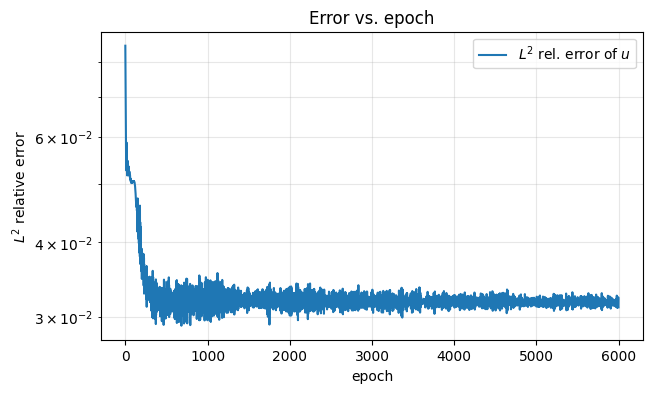

In [ ]:

# Error vs. epoch curve (L2 relative error on the testing dataset)

plt.figure(figsize=(7, 4))
plt.semilogy(history['err_u'], label=r'$L^2$ rel. error of $u$')
plt.xlabel('epoch'); plt.ylabel(r'$L^2$ relative error')
plt.title('Error vs. epoch')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.show()

Loaded best checkpoint from epoch 5445
FINAL L2 relative error of u: 3.2071e-02


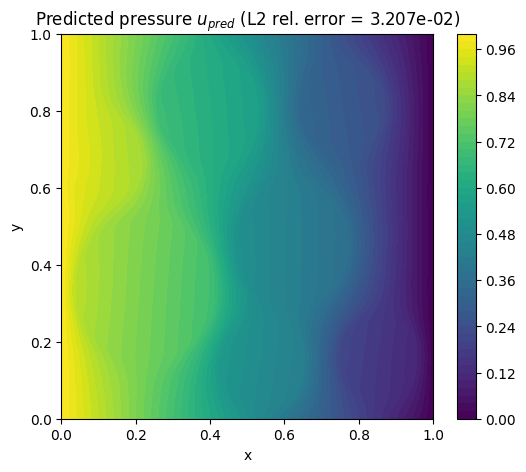

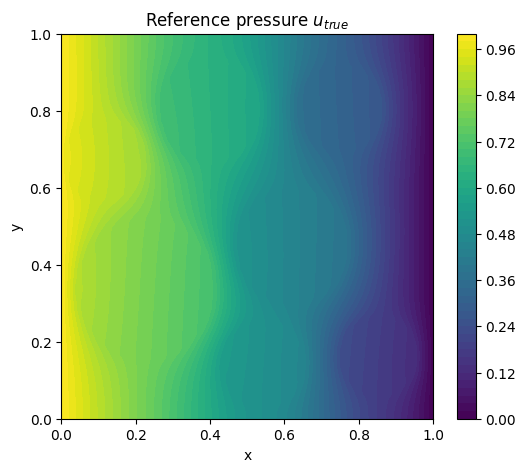

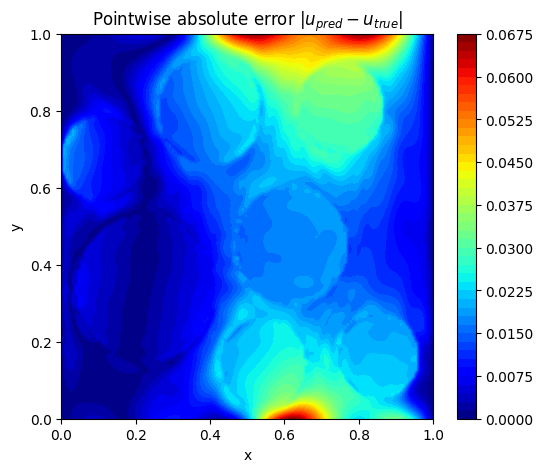

In [ ]:

# Inference with the best checkpoint + required result figures

checkpoint = torch.load(os.path.join(CKPT_DIR, 'best_model.pt'), map_location=device, weights_only=True)
model_u.load_state_dict(checkpoint['model_u'])
print(f"Loaded best checkpoint from epoch {checkpoint['epoch']}")

with torch.no_grad():
    u_pred = model_u(x_test_dev).cpu().numpy().reshape(128, 128)

u_true_grid = u_test.numpy().reshape(128, 128)
X1 = x_test[:, 0].reshape(128, 128); X2 = x_test[:, 1].reshape(128, 128)
err_final = loss_fn.get_error(x_test_dev, u_test_dev)
print(f'FINAL L2 relative error of u: {err_final:.4e}')

#Figure: predicted pressure field
plt.figure(figsize=(6, 5))
cntr = plt.contourf(X1, X2, u_pred, levels=50)
plt.colorbar(cntr); plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Predicted pressure $u_{{pred}}$ (L2 rel. error = {err_final:.3e})')
plt.show()

# Figure: ground truth reference
plt.figure(figsize=(6, 5))
cntr = plt.contourf(X1, X2, u_true_grid, levels=50)
plt.colorbar(cntr); plt.xlabel('x'); plt.ylabel('y')
plt.title('Reference pressure $u_{true}$')
plt.show()

# Figure: pointwise absolute error
plt.figure(figsize=(6, 5))
cntr = plt.contourf(X1, X2, np.abs(u_pred - u_true_grid), levels=50, cmap='jet')
plt.colorbar(cntr); plt.xlabel('x'); plt.ylabel('y')
plt.title(r'Pointwise absolute error $|u_{pred} - u_{true}|$')
plt.show()

## Implementation setup (summary for the report)

| Component | Choice |
|---|---|
| Method | Deep Ritz (variational energy minimization) |
| Network structure | MLP $[2, 80, 80, 80, 80, 1]$, $\tanh$ activations (~20k parameters) |
| Output transform | $u_\theta = (1-x_1) + x_1(1-x_1)x_2(1-x_2)\mathcal{N}(x)$ (exact Dirichlet BCs) |
| Loss | Monte-Carlo Ritz energy $\overline{\tfrac{\mu}{2}|\nabla u_\theta|^2}$, stratified per-pixel sampling ($128^2$ pts/epoch) |
| Optimizer | Adam, lr $10^{-3}$, StepLR decay $\times 0.6$ every $1200$ epochs |
| Epochs / batch | $6000$ epochs, full batch ($16384$ stratified points resampled per epoch) |
| Loss weights | none needed (hard BCs $\Rightarrow$ single energy term) |
| Tricks | hard boundary constraint, stratified sampling, input normalization, resampling, best-energy checkpointing |
| Random seed | 1234 (numpy + torch) |

**Interpretation.** The pressure field is recovered to $\approx 3\%$ relative $L^2$ error. The pointwise error
concentrates along the phase interfaces, where the exact solution has a kinked gradient that the smooth $\tanh$
ansatz can only approximate .The known accuracy limit of global smooth ansatz functions for interface problems.

### Additional figures for the report: error vs. phase interfaces, and a cross-section

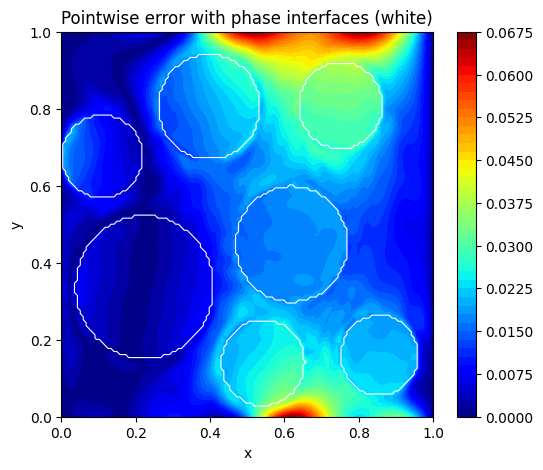

In [ ]:
# Extra figure 1: pointwise error with the phase interfaces overlaid

import os
os.makedirs('figures', exist_ok=True)
mu_plot = fun_mu(x_test).reshape(128, 128)

plt.figure(figsize=(6, 5))
c = plt.contourf(X1, X2, np.abs(u_pred - u_true_grid), levels=50, cmap='jet')
plt.colorbar(c)
plt.contour(X1, X2, mu_plot, levels=[6.], colors='white', linewidths=0.8)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Pointwise error with phase interfaces (white)')
plt.savefig('figures/B_err_interfaces.png', dpi=200, bbox_inches='tight')
plt.show()

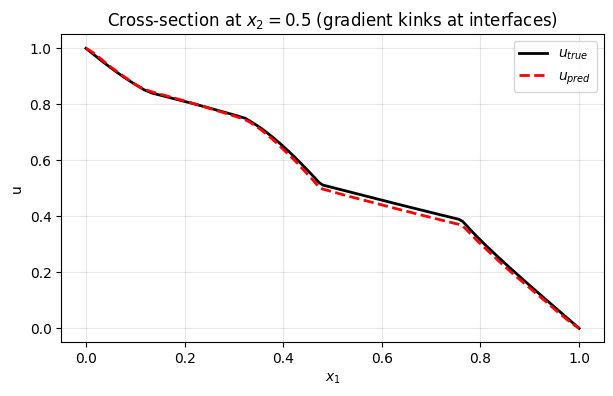

In [ ]:

# Extra figure 2: cross-section through the domain at x2 ~ 0.5

X1n, X2n = X1.numpy(), X2.numpy()
if abs(X2n[0, 0] - X2n[-1, 0]) > abs(X2n[0, 0] - X2n[0, -1]):
    i = np.argmin(np.abs(X2n[:, 0] - 0.5))
    xs, up, ut = X1n[i, :], u_pred[i, :], u_true_grid[i, :]
else:
    i = np.argmin(np.abs(X2n[0, :] - 0.5))
    xs, up, ut = X1n[:, i], u_pred[:, i], u_true_grid[:, i]

plt.figure(figsize=(7, 4))
plt.plot(xs, ut, 'k-', lw=2, label=r'$u_{true}$')
plt.plot(xs, up, 'r--', lw=2, label=r'$u_{pred}$')
plt.xlabel(r'$x_1$'); plt.ylabel('u')
plt.title(r'Cross-section at $x_2 = 0.5$ (gradient kinks at interfaces)')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('figures/B_crosssection.png', dpi=200, bbox_inches='tight')
plt.show()